## 1. import data set

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive', readonly=True)

Mounted at /content/drive


In [ ]:
#!mkdir /content/dataset
#!tar -xf '/content/drive/My Drive/ECE 1508 APLDL/dataset/OCT_clean.tar' -C /content/dataset

## 2. prepare dataset

In [12]:
import os

# Define the path to the training dataset
#train_data_path = '/content/dataset/OCT_clean/train'
dataset_path = os.path.join(r'C:\Users\ck\Downloads\CellData\OCT_clean')
train_data_path = os.path.join(dataset_path, 'train')

# Get a list of all items in the train_data_path
categories = [d for d in os.listdir(train_data_path) if os.path.isdir(os.path.join(train_data_path, d))]

print("Number of samples per category in the training dataset:")
for category in categories:
    category_path = os.path.join(train_data_path, category)
    num_samples = len(os.listdir(category_path))
    print(f"  {category}: {num_samples} samples")


Number of samples per category in the training dataset:
  CNV: 74410 samples
  DME: 22696 samples
  DRUSEN: 17232 samples
  NORMAL: 102280 samples


## Load and Preprocess OCT Data

### Subtask:
Load the OCT images, apply necessary transformations (resizing, normalization), and create data loaders for training and validation sets.


**Reasoning**:
The first step is to import the necessary libraries for image transformations and data loading, as specified in the instructions. This includes `torch`, `torchvision.transforms`, `torchvision.datasets.ImageFolder`, and `torch.utils.data.DataLoader`.



In [9]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

**Reasoning**:
Following the instructions, I will define the image transformations for both training and validation sets, create ImageFolder datasets from the specified paths, and then set up DataLoader objects with appropriate batch sizes and shuffling for each set. This completes the data loading and preprocessing subtask.



**Reasoning**:
The previous code failed because the validation directory '/content/dataset/OCT_clean/val' was not found, leading to a `NameError` for `val_dataset`. I will modify the code to handle this by checking if the validation directory exists. If it doesn't, I will split the training dataset into training and validation sets using `random_split` to ensure `val_dataset` is always defined and the program can continue.



In [25]:
import random
from torch.utils.data import Dataset
from torchvision.datasets import ImageFolder

class FilteredLimitedImageFolder(ImageFolder):
    def __init__(self, root, transform=None, max_samples_per_class=None):
        super(FilteredLimitedImageFolder, self).__init__(root, transform=transform)
        self.max_samples_per_class = max_samples_per_class

        # Store original samples before filtering/limiting for class-wise processing
        original_samples = list(self.samples)
        self.samples = []
        self.imgs = []

        if max_samples_per_class is not None:
            # Group samples by class
            samples_by_class = {cls_idx: [] for cls_idx in range(len(self.classes))}
            for path, label in original_samples:
                if '_original' in path.lower():
                    samples_by_class[label].append((path, label))

            # Stratified sampling
            for cls_idx in sorted(samples_by_class.keys()):
                class_samples = samples_by_class[cls_idx]
                # Shuffle samples for the current class to ensure random selection
                random.shuffle(class_samples)
                # Take up to max_samples_per_class
                self.samples.extend(class_samples[:max_samples_per_class])
        else:
            # If no max_samples_per_class, just filter by '_original'
            for path, label in original_samples:
                if '_original' in path.lower():
                    self.samples.append((path, label))

        # Shuffle the final list of samples
        random.shuffle(self.samples)
        self.imgs = self.samples

        print(f"Initialized FilteredLimitedImageFolder with {len(self.samples)} samples from {root} (stratified sampling).")

print("FilteredLimitedImageFolder class defined successfully with stratified sampling capability.")

FilteredLimitedImageFolder class defined successfully with stratified sampling capability.


In [26]:
import os
from torch.utils.data import random_split

image_size = 224
batch_size = 32

# Define maximum number of samples PER CLASS for training and validation
# To get approximately 10000 total samples with 4 classes, we aim for 2500 per class.
max_samples_per_class_train = 2500 # 2500 samples per class * 4 classes = 10000 total
max_samples_per_class_val = 500   # 500 samples per class * 4 classes = 2000 total

# 2. Define transformations for the training data
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Define transformations for the validation data
val_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define paths for training and validation data
train_data_path = os.path.join(dataset_path, 'train')
val_data_path = os.path.join(dataset_path, 'test')

# 4. Create FilteredLimitedImageFolder datasets with stratified sampling
train_dataset = FilteredLimitedImageFolder(root=train_data_path, transform=train_transforms, max_samples_per_class=max_samples_per_class_train)
val_dataset = FilteredLimitedImageFolder(root=val_data_path, transform=val_transforms, max_samples_per_class=max_samples_per_class_val)

# 5. Create DataLoader objects
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with batch size: {batch_size}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")

Initialized FilteredLimitedImageFolder with 10000 samples from C:\Users\ck\Downloads\CellData\OCT_clean\train (stratified sampling).
Initialized FilteredLimitedImageFolder with 1000 samples from C:\Users\ck\Downloads\CellData\OCT_clean\test (stratified sampling).
DataLoaders created with batch size: 32
Number of batches in training loader: 313
Number of batches in validation loader: 32


## Define ResNet-like Model Architecture


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


In [20]:
class ResNet_Like(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super(ResNet_Like, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for i in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Get the number of output classes dynamically
num_classes = len(train_dataset.dataset.classes) if hasattr(train_dataset, 'dataset') else len(train_dataset.classes)

# Instantiate the ResNet-like model (using ResNet-18 like configuration)
model = ResNet_Like(ResidualBlock, [2, 2, 2, 2], num_classes=num_classes)

# Move model to appropriate device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"ResNet_Like model defined and instantiated with {num_classes} output classes.")
print(f"Model moved to device: {device}")

ResNet_Like model defined and instantiated with 4 output classes.
Model moved to device: cuda


## Configure Training Parameters

Set up the loss function (e.g., CrossEntropyLoss), optimizer (e.g., Adam), learning rate scheduler, and define the number of epochs for training.


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

In [22]:
learning_rate = 0.001
num_epochs = 10

# 1. Define the loss function
criterion = nn.CrossEntropyLoss()

# 2. Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 3. Define the number of training epochs (already set above)

print(f"Loss function (criterion) defined: {criterion}")
print(f"Optimizer defined: {optimizer}")
print(f"Number of epochs set to: {num_epochs}")

Loss function (criterion) defined: CrossEntropyLoss()
Optimizer defined: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Number of epochs set to: 10


## Train the Model

Implement the training loop to iterate through the dataset, perform forward and backward passes, and update model weights. Monitor training and validation loss/accuracy during this phase.


In [27]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

In [28]:
import time

for epoch in range(num_epochs):
    start_time = time.time()

    # Training Phase
    model.train()  # Set model to training mode
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation Phase
    model.eval()  # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():  # Disable gradient calculation during validation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_accuracy = 100 * correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    end_time = time.time()
    epoch_duration = end_time - start_time

    print(f'Epoch [{epoch+1}/{num_epochs}], ' \
          f'Train Loss: {epoch_train_loss:.4f}, ' \
          f'Train Acc: {epoch_train_accuracy:.2f}%, ' \
          f'Val Loss: {epoch_val_loss:.4f}, ' \
          f'Val Acc: {epoch_val_accuracy:.2f}% (Duration: {epoch_duration:.2f}s)')

print("Training complete.")

Epoch [1/10], Train Loss: 1.2103, Train Acc: 47.76%, Val Loss: 1.1611, Val Acc: 55.10% (Duration: 173.14s)
Epoch [2/10], Train Loss: 0.6681, Train Acc: 73.87%, Val Loss: 5.1274, Val Acc: 25.70% (Duration: 65.21s)
Epoch [3/10], Train Loss: 0.5070, Train Acc: 80.86%, Val Loss: 0.5699, Val Acc: 78.60% (Duration: 65.22s)
Epoch [4/10], Train Loss: 0.4184, Train Acc: 85.11%, Val Loss: 1.2565, Val Acc: 65.40% (Duration: 65.75s)
Epoch [5/10], Train Loss: 0.3726, Train Acc: 86.69%, Val Loss: 0.2345, Val Acc: 91.20% (Duration: 65.47s)
Epoch [6/10], Train Loss: 0.3505, Train Acc: 87.22%, Val Loss: 0.7310, Val Acc: 76.60% (Duration: 65.64s)
Epoch [7/10], Train Loss: 0.3104, Train Acc: 89.15%, Val Loss: 0.5235, Val Acc: 82.00% (Duration: 65.80s)
Epoch [8/10], Train Loss: 0.2948, Train Acc: 89.55%, Val Loss: 0.4604, Val Acc: 82.20% (Duration: 65.70s)
Epoch [9/10], Train Loss: 0.2720, Train Acc: 90.32%, Val Loss: 0.2772, Val Acc: 89.90% (Duration: 65.84s)
Epoch [10/10], Train Loss: 0.2633, Train Acc:

## 6. Save the Trained Model

Save the trained model's weights to a file so it can be loaded later for inference or further training.

In [29]:
import torch
import os

# Define a path to save the model
model_save_path = 'resnet_like_oct_classifier.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully to {model_save_path}")

Model saved successfully to resnet_like_oct_classifier.pth


## 7. Test Model on a Random Sample from the Test Set

Randomly select an image from the validation (test) set, display it, and show the model's prediction along with the true label.

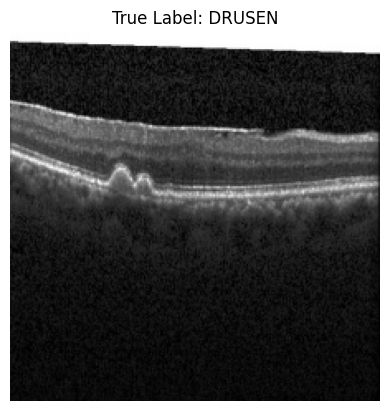


Model Prediction: DRUSEN
True Label: DRUSEN
Prediction: CORRECT!


In [32]:
import random
import numpy as np

# Define denormalization transformations once (reverse of normalization)
# mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
inv_normalize_transform = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def display_tensor_image(tensor_image, title=""):
    """Helper function to display a PyTorch image tensor."""
    img_display = inv_normalize_transform(tensor_image)
    img_display = img_display.numpy().transpose((1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
    img_display = np.clip(img_display, 0, 1) # Clip values to [0, 1] range

    plt.imshow(img_display)
    plt.title(title)
    plt.axis('off')
    plt.show()

# 1. Select a random image from the validation dataset
random_idx = random.randint(0, len(val_dataset) - 1)
sample_image, true_label_idx = val_dataset[random_idx]

# Get the true class name
true_class_name = val_dataset.classes[true_label_idx]

# 2. Display the image using the helper function
display_tensor_image(sample_image, title=f"True Label: {true_class_name}")

# 3. Test the model effect on this image
model.eval() # Set model to evaluation mode
with torch.no_grad():
    # Add a batch dimension to the single image (C, H, W) -> (1, C, H, W)
    input_image = sample_image.unsqueeze(0).to(device)
    output = model(input_image)
    _, predicted_label_idx = torch.max(output, 1)
    predicted_class_name = val_dataset.classes[predicted_label_idx.item()]

print(f"\nModel Prediction: {predicted_class_name}")
print(f"True Label: {true_class_name}")

if predicted_class_name == true_class_name:
    print("Prediction: CORRECT!")
else:
    print("Prediction: INCORRECT!")